In [2]:
import pandas as pd
customers = pd.read_csv('../data/processed/customer_features.csv', dtype={'Customer ID': str})
print(customers.columns.tolist())
print(customers.shape)

['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts', 'ReturnCount', 'Tenure', 'FirstPurchase', 'LastPurchase', 'PreferredDayOfWeek', 'PreferredMonth', 'ReturnRate', 'Country', 'Churned']
(5878, 16)


In [3]:
# ============================================================
# CELL 1: Imports and Load Model + Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42

# Load customer features
customers = pd.read_csv(
    '../data/processed/customer_features.csv',
    dtype={'Customer ID': str}
)

# Encode country only
le_country = LabelEncoder()
customers['Country_encoded'] = le_country.fit_transform(customers['Country'])

FEATURE_COLS = [
    'Frequency', 'Monetary',
    'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts',
    'Tenure', 'ReturnRate', 'ReturnCount',
    'PreferredDayOfWeek', 'PreferredMonth',
    'Country_encoded'
]

X = customers[FEATURE_COLS]
y = customers['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS)

# Load saved model
model = joblib.load('../models/saved/churn_model_catboost.pkl')

print("Model and data loaded successfully")
print(f"Test set size: {X_test_df.shape[0]:,} customers")
print(f"Columns in dataset: {customers.columns.tolist()}")

Model and data loaded successfully
Test set size: 1,176 customers
Columns in dataset: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'AvgBasketSize', 'UniqueProducts', 'ReturnCount', 'Tenure', 'FirstPurchase', 'LastPurchase', 'PreferredDayOfWeek', 'PreferredMonth', 'ReturnRate', 'Country', 'Churned', 'Cluster', 'Persona', 'Country_encoded']


Calculating SHAP values (this takes ~30 seconds)...
SHAP values calculated.


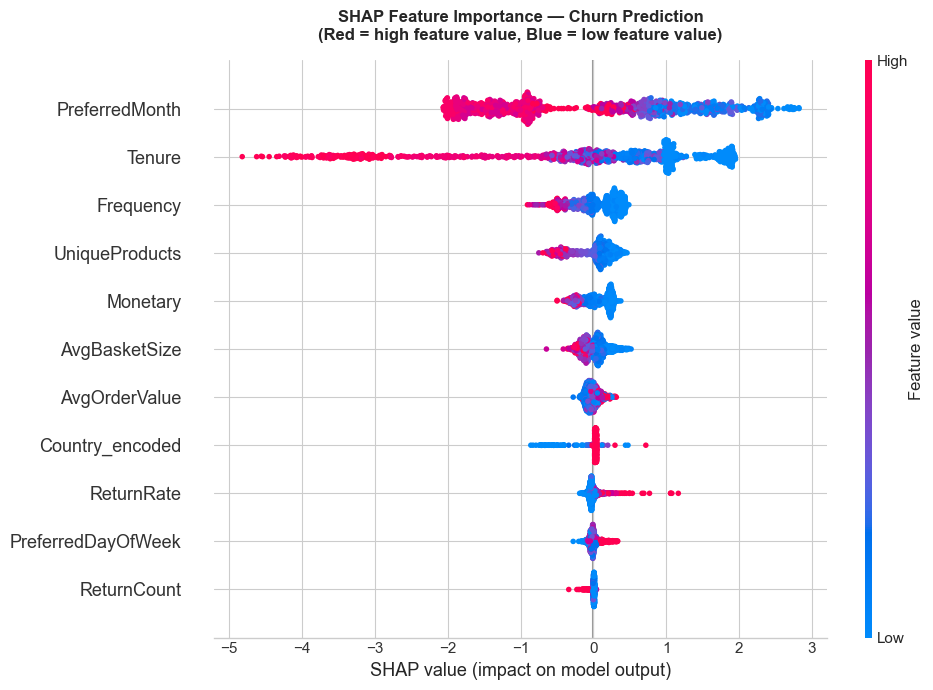

Saved: reports/figures/14_shap_summary.png


In [4]:
# ============================================================
# CELL 2: SHAP Global Explanation
# ============================================================
# SHAP Summary Plot shows:
# - Y-axis: features ranked by importance (most important at top)
# - X-axis: SHAP value (positive = pushes toward churn,
#                        negative = pushes away from churn)
# - Color: feature value (red=high, blue=low)
#
# How to read it:
# If Monetary has blue dots on the left side → low monetary
# value customers are pushed toward churn. Makes sense.

print("Calculating SHAP values (this takes ~30 seconds)...")

# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)

print("SHAP values calculated.")

# Summary plot — most important visualization in XAI
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None
)
plt.title('SHAP Feature Importance — Churn Prediction\n'
          '(Red = high feature value, Blue = low feature value)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/14_shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/figures/14_shap_summary.png")

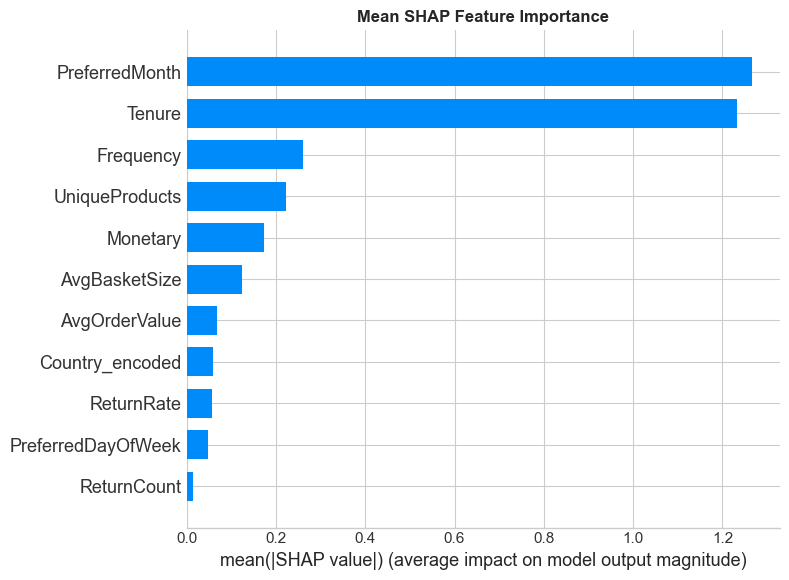


Feature Importance Ranking (by mean |SHAP value|):
  PreferredMonth         1.2657  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Tenure                 1.2322  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Frequency              0.2602  ██████████████████████████
  UniqueProducts         0.2233  ██████████████████████
  Monetary               0.1738  █████████████████
  AvgBasketSize          0.1251  ████████████
  AvgOrderValue          0.0689  ██████
  Country_encoded        0.0602  ██████
  ReturnRate             0.0568  █████
  PreferredDayOfWeek     0.0490  ████
  ReturnCount            0.0136  █


In [5]:
# ============================================================
# CELL 3: SHAP Mean Importance Bar Plot
# ============================================================
# Simpler version of the summary plot — just shows the
# average SHAP impact of each feature.
# This is the version you show to non-technical stakeholders.

shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('Mean SHAP Feature Importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/15_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print ranked feature importance
mean_shap = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print("\nFeature Importance Ranking (by mean |SHAP value|):")
print("=" * 45)
for _, row in mean_shap.iterrows():
    bar = "█" * int(row['Mean_SHAP'] * 100)
    print(f"  {row['Feature']:<22} {row['Mean_SHAP']:.4f}  {bar}")

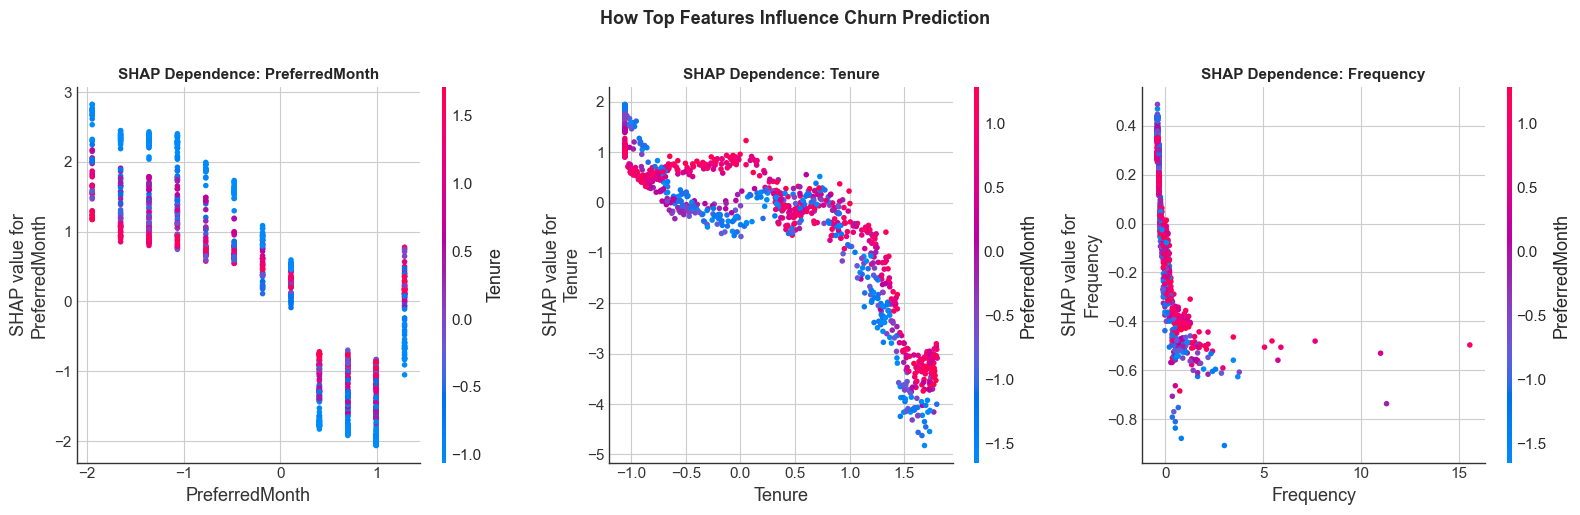

In [6]:
# ============================================================
# CELL 4: SHAP Dependence Plots — Top 3 Features
# ============================================================
# Dependence plot shows HOW a feature affects churn prediction
# X-axis: actual feature value
# Y-axis: SHAP value (impact on prediction)
# Color: interaction with another feature (auto-selected)
#
# This answers: "At what point does Monetary value
# stop protecting against churn?"

top_3_features = mean_shap['Feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feature in enumerate(top_3_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_df,
        feature_names=FEATURE_COLS,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feature}',
                      fontsize=11, fontweight='bold')

plt.suptitle('How Top Features Influence Churn Prediction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/16_shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()

High risk customer — Churn probability: 99.8%
Low risk customer  — Churn probability: 0.4%

--- HIGH RISK CUSTOMER EXPLANATION ---


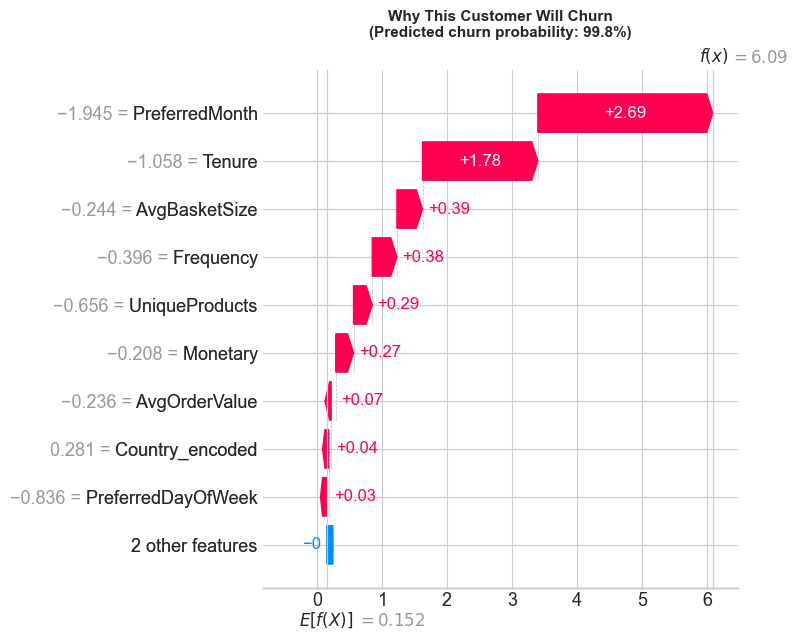


--- LOW RISK CUSTOMER EXPLANATION ---


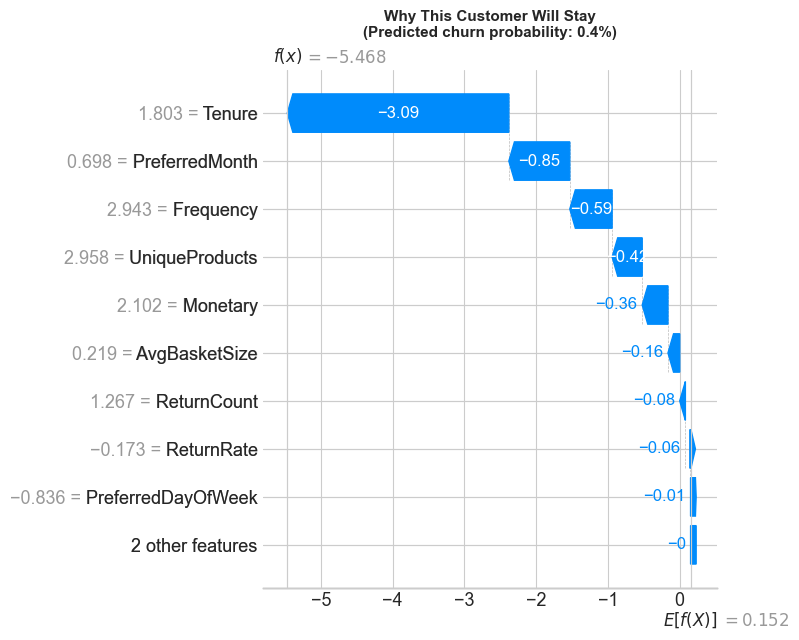

In [7]:
# ============================================================
# CELL 5: Explain Individual Predictions
# ============================================================
# This is the most powerful business use of SHAP.
# For any single customer, we can say:
# "This customer is predicted to churn because their
#  Monetary value is low AND they haven't bought recently"
#
# This is what a marketing team needs to take action.

# Pick one high-risk churner and one safe customer
churn_proba = model.predict_proba(X_test_df)[:, 1]
X_test_reset = X_test_df.reset_index(drop=True)

# Highest churn risk customer
high_risk_idx = np.argmax(churn_proba)

# Lowest churn risk customer
low_risk_idx = np.argmin(churn_proba)

print(f"High risk customer — Churn probability: {churn_proba[high_risk_idx]:.1%}")
print(f"Low risk customer  — Churn probability: {churn_proba[low_risk_idx]:.1%}")

# Waterfall plot for high risk customer
print("\n--- HIGH RISK CUSTOMER EXPLANATION ---")
shap_display = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[high_risk_idx].values,
    feature_names=FEATURE_COLS
)
shap.plots.waterfall(shap_display, show=False)
plt.title(f'Why This Customer Will Churn\n'
          f'(Predicted churn probability: {churn_proba[high_risk_idx]:.1%})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/17_shap_waterfall_highrisk.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Waterfall plot for low risk customer
print("\n--- LOW RISK CUSTOMER EXPLANATION ---")
shap_display_low = shap.Explanation(
    values=shap_values[low_risk_idx],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[low_risk_idx].values,
    feature_names=FEATURE_COLS
)
shap.plots.waterfall(shap_display_low, show=False)
plt.title(f'Why This Customer Will Stay\n'
          f'(Predicted churn probability: {churn_proba[low_risk_idx]:.1%})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/17_shap_waterfall_lowrisk.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# CELL 6: Business Insights from SHAP
# ============================================================
# Translate technical SHAP findings into business language
# This is what goes in your README and portfolio writeup

print("=" * 60)
print("BUSINESS INSIGHTS FROM SHAP ANALYSIS")
print("=" * 60)

top_features = mean_shap.head(5)

print("""
KEY FINDINGS:
─────────────────────────────────────────────────────────────

1. TOP CHURN DRIVERS
   The most influential features predicting churn are:""")

for _, row in top_features.iterrows():
    print(f"   • {row['Feature']:<22} (SHAP importance: {row['Mean_SHAP']:.4f})")

print("""
2. WHAT PROTECTS AGAINST CHURN
   • High Monetary value customers are significantly less
     likely to churn — they have more investment in the brand
   • High Frequency buyers have established purchase habits
     that are hard to break
   • Long Tenure customers (high Tenure) are sticky —
     they've been loyal for years

3. WHAT DRIVES CHURN
   • Low Frequency (1-2 purchases) is the strongest churn signal
   • Low Monetary value combined with low UniqueProducts
     suggests one-off buyers with no brand attachment
   • High ReturnRate signals dissatisfaction

4. BUSINESS RECOMMENDATIONS
   • Target win-back campaigns at customers with
     Frequency=2-3 and declining Monetary value
   • Loyalty programs should focus on customers with
     Tenure > 180 days to lock in habit formation
   • Flag customers with ReturnRate > 0.5 for
     proactive customer service outreach

─────────────────────────────────────────────────────────────
""")
print("=" * 60)
print("All SHAP plots saved to reports/figures/")

BUSINESS INSIGHTS FROM SHAP ANALYSIS

KEY FINDINGS:
─────────────────────────────────────────────────────────────

1. TOP CHURN DRIVERS
   The most influential features predicting churn are:
   • PreferredMonth         (SHAP importance: 1.2657)
   • Tenure                 (SHAP importance: 1.2322)
   • Frequency              (SHAP importance: 0.2602)
   • UniqueProducts         (SHAP importance: 0.2233)
   • Monetary               (SHAP importance: 0.1738)

2. WHAT PROTECTS AGAINST CHURN
   • High Monetary value customers are significantly less
     likely to churn — they have more investment in the brand
   • High Frequency buyers have established purchase habits
     that are hard to break
   • Long Tenure customers (high Tenure) are sticky —
     they've been loyal for years

3. WHAT DRIVES CHURN
   • Low Frequency (1-2 purchases) is the strongest churn signal
   • Low Monetary value combined with low UniqueProducts
     suggests one-off buyers with no brand attachment
   • High Ret